In [ ]:
# import numpy as np
# import math
scale = 8695
shape = 2.25
MTTF = scale * math.gamma(1+1/shape)
print(MTTF)

7701.426302387307


Adding a single sensor to a exponential component

In [ ]:
from sensor_objects.quality_based_sensor import QualityBasedSensor
from component_objects.component_exponential import ExponentialComponent
# from sensed_objects.majority_vote_sensed_comp import MajorityVoteSensedComp
from sensed_objects.kooN_vote_sensed_comp import KooNVoteSensedComp

import matplotlib.pyplot as plt

# initialize comp and sensor 
comp = ExponentialComponent("test comp", MTTF= 5, MTTR=2)
sensor = QualityBasedSensor("s1", comp, quality= "Moderate")

sim_hours = 10
dt = 0.5
sensed_comp = KooNVoteSensedComp(comp, [sensor], k=2)
sensed_comp.simulate(t_end=sim_hours, dt=dt)
sensed_comp.plot_history()

print(f"The sensing accuracy is {sum(sensor.history[:,1] / len(sensor.history)):.2%}")
sensed_comp.all_states

Sensed Comp with Multiple Sensors

In [ ]:
from sensor_objects.quality_based_sensor import QualityBasedSensor
from component_objects.component_exponential import ExponentialComponent
from sensed_objects.majority_vote_sensed_comp import MajorityVoteSensedComp

import matplotlib.pyplot as plt

# initialize comp and sensor 
comp = ExponentialComponent("test comp", MTTF= 5, MTTR=2)
num_sensors = 3
sensors = [QualityBasedSensor(f"s{i}", comp, quality= "Moderate") for i in range(num_sensors)]

sim_hours = 10
dt = 1
sensed_comp = MajorityVoteSensedComp(comp, sensors)
sensed_comp.simulate(t_end=sim_hours, dt=dt)
sensed_comp.plot_history()

# print(f"The sensing accuracy is {sum(sensor.history[:,1] / len(sensor.history)):.2%}")
sensed_comp.all_states

Comparing the accuracy of a Good vs Moderate vs Bad Single Sensor

Good Sensor Accuracy = 19.05%
Moderate Sensor Accuracy = 28.57%
Bad Sensor Accuracy = 47.62%
[[ 0.   1. ]
 [ 0.5  1. ]
 [ 1.   1. ]
 [ 1.5  1. ]
 [ 2.   1. ]
 [ 2.5  1. ]
 [ 3.   1. ]
 [ 3.5  1. ]
 [ 4.   1. ]
 [ 4.5  1. ]
 [ 5.   1. ]
 [ 5.5  1. ]
 [ 6.   1. ]
 [ 6.5  1. ]
 [ 7.   1. ]
 [ 7.5  1. ]
 [ 8.   1. ]
 [ 8.5  0. ]
 [ 9.   0. ]
 [ 9.5  0. ]
 [10.   0. ]]


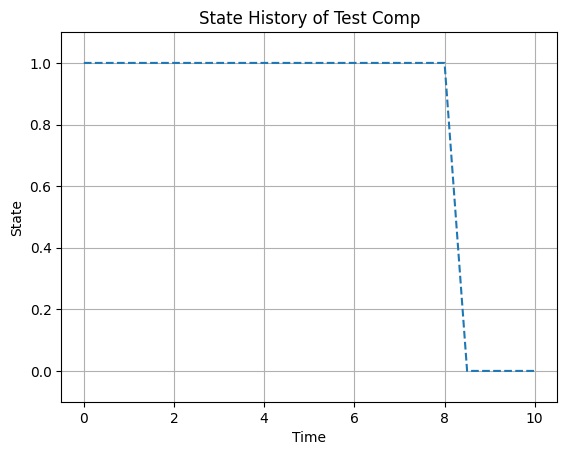

In [5]:
from sensor_objects.quality_based_sensor import QualityBasedSensor
from component_objects.component_exponential import ExponentialComponent
from component_objects.component_weibull import WeibullComponent

import matplotlib.pyplot as plt
import numpy as np

# initialize a common comp
comp = WeibullComponent("test comp", MTTF= 10, MTTR=2)

# initialize 3 different types of sensors
s1 = QualityBasedSensor("s_good", comp, quality= "Good")
s2 = QualityBasedSensor("s_moderate", comp, quality= "Moderate")
s3 = QualityBasedSensor("s_bad", comp, quality= "Bad")

# simulate history and read with all sensors
sim_hours = 10
dt = 0.5
comp.simulate(sim_hours, dt)
comp.plot_history()
s1.simulate(sim_hours, dt)
s2.simulate(sim_hours, dt)
s3.simulate(sim_hours, dt)

# check accuracy of each sensor
accuracy1 = np.sum(s1.sensed_history[:,1] == comp.history[1:,1]) / len(comp.history)
accuracy_times = np.sum(s1.sensed_history[:,0]== comp.history[1:,0])
accuracy2 = np.sum(s2.sensed_history[:,1] == comp.history[1:,1]) / len(comp.history)
accuracy3 = np.sum(s3.sensed_history[:,1] == comp.history[1:,1]) / len(comp.history)

# print the accuracy of each sensor type 
print(f"Good Sensor Accuracy = {accuracy1:.2%}")
print(f"Moderate Sensor Accuracy = {accuracy2:.2%}")
print(f"Bad Sensor Accuracy = {accuracy3:.2%}")


print(comp.history)

Checking the History vs. Sensed History of the sensors

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
comp.plot_history()
s1.plot_history('sensed')

plt.figure()
s1.plot_history('truth')


Combined Sensor Readings for Multiple Moderate Sensors attached to one component

In [ ]:
from sensor_objects.quality_based_sensor import QualityBasedSensor
from component_objects.component_exponential import ExponentialComponent
# from component_objects.component_weibull import WeibullComponent
from sensed_objects.majority_vote_sensed_comp import MajorityVoteSensedComp

import matplotlib.pyplot as plt

# initialize a component and multiple sensors
comp = ExponentialComponent("Comp w/ Multiple Sensors", MTTF=10, MTTR=2)
num_sensors = 5
sensors = [QualityBasedSensor(f"s{i+1}", comp, "Moderate") for i in range(num_sensors)]

# initialize the comp and sensors as a paired object
sc = MajorityVoteSensedComp(comp, sensors)

# attempt to simulate the sensed component and print the truth and sensed readings
sim_hours = 25
dt = 0.5
sc.simulate(sim_hours, dt)

plt.plot(sc.history[:,0], sc.history[:,1])
plt.plot(sc.sensed_history[:,0], sc.sensed_history[:,1], '--')

Simulate a kooN Sensed Comp with 3 sensors and various k

In [13]:
import math

# single sensor correct 
k = 1 
n = 3
solution = math.comb(n, k) * 0.98**k * (1-0.98)**(n-k)
print(solution)

# 2 sensors correct 
k = 2 
n = 3
solution = math.comb(n, k) * 0.98**k * (1-0.98)**(n-k)
print(solution)

# 3 sensors correct
k = 3 
n = 3
solution = math.comb(n, k) * 0.98**k * (1-0.98)**(n-k)
print(solution)


0.0011760000000000021
0.05762400000000004
0.9411919999999999


In [15]:
import math
from math import comb
import numpy as np

def k_of_n_identical(N: int, K: int, p: float) -> float:
    """Probability that K-of-N fusion is correct when all sensors have the same p."""
    if not (0 <= p <= 1):
        raise ValueError("p must be in [0,1]")
    if K <= 0:
        return 1.0
    if K > N:
        return 0.0
    # sum binomial tail
    total = 0.0
    for i in range(K, N+1):
        total += comb(N, i) * (p**i) * ((1-p)**(N-i))
    return total


# def k_of_n_heterogeneous(ps: list[float], K: int) -> float:
#     """
#     Poisson-Binomial DP to compute probability at least K sensors correct.
#     ps: list of per-sensor correctness probabilities p_i
#     K: required number of correct sensors
#     Returns P(#correct >= K).
#     Complexity: O(N^2) time, O(N) memory.
#     """
#     N = len(ps)
#     if K <= 0:
#         return 1.0
#     if K > N:
#         return 0.0

#     # dp[j] = probability exactly j sensors are correct after processing some sensors
#     dp = np.zeros(N+1, dtype=float)
#     dp[0] = 1.0

#     for p in ps:
#         # iterate j from current max down to 0 to avoid overwriting needed values
#         # new_dp[j] = dp[j] * (1-p) + dp[j-1] * p
#         # we update in-place by iterating backwards
#         for j in range(N, 0, -1):
#             dp[j] = dp[j] * (1 - p) + dp[j-1] * p
#         dp[0] = dp[0] * (1 - p)

#     # sum tail probabilities
#     return float(dp[K:].sum())


# -----------------------
# Examples
# -----------------------
if __name__ == "__main__":
    # identical p example: N=3, p=0.98
    N = 3
    p = 0.98
    for K in (1,2,3):
        print(f"N={N}, p={p:.3f}, K={K} -> P = {k_of_n_identical(N, K, p):.6f}")

    # # heterogeneous example: three sensors with same p (should match above)
    # ps = [0.98, 0.98, 0.98]
    # for K in (1,2,3):
    #     print(f"ps={ps}, K={K} -> P = {k_of_n_heterogeneous(ps, K):.6f}")

    # # heterogeneous different probabilities
    # ps2 = [0.98, 0.90, 0.85]
    # for K in (1,2,3):
    #     print(f"ps={ps2}, K={K} -> P = {k_of_n_heterogeneous(ps2, K):.6f}")


N=3, p=0.980, K=1 -> P = 0.999992
N=3, p=0.980, K=2 -> P = 0.998816
N=3, p=0.980, K=3 -> P = 0.941192
